# Welcome to CDState tutorial

This tutorial gets you through use-case run of CDState, with calculation of tumor purity for input samples, running CDState and calculating the ITTH index. 

### Loading packages
First we load all necessary packages, along with CDState base code:

In [18]:
%load_ext rpy2.ipython
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))
import CDState_base as cd
import pandas as pd
import copy
import numpy as np
import sklearn, random

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


We will run CDState using one of the bulkified cancer datasets (available in the `data` directory)

In [2]:
root = Path.cwd().parent
file_path = root / "data" / "bulkified_cancer" / "GBM"

data = pd.read_csv(file_path / "Neftel_GBM_SS2_bulkified_sum_v2.txt", index_col=0,sep=',',header=0)
proportions = pd.read_csv(file_path / "Neftel_GBM_SS2_proportions_sum_v2.txt", index_col=0,sep=',',header=0)


In [3]:
data

,MGH100,MGH101,MGH102,MGH104,MGH105,MGH106,MGH110,MGH113,MGH115,MGH121,...,MGH151,MGH152,MGH66,BT1160,BT1187,BT749,BT771,BT786,BT830,BT920
A1BG,10.084260,0.444100,2.797397,0.544704,3.235930,8.562049,1.192005,7.500192,4.320606,4.536869,...,5.371472,5.441834,0.460023,1.687452,1.318163,1.161923,5.545517,0.137214,6.176110,6.515257
A1BG-AS1,14.816793,0.038600,3.340818,2.125352,6.340551,11.844500,1.258357,7.708193,7.984606,9.165522,...,6.991901,10.699869,1.561835,2.224369,6.484097,2.561195,7.929215,0.189951,8.162261,10.201114
A1CF,0.084163,0.039100,0.143941,0.100704,0.073170,0.061350,0.222563,0.015154,0.047879,0.060337,...,0.135399,0.075284,0.046284,0.091015,0.037671,0.166373,0.198260,0.134623,0.102227,0.052259
A2M,75.206850,455.412930,677.667300,89.730310,695.968260,107.001144,14.090946,142.130770,58.621696,0.128283,...,0.408405,288.939600,11.238671,4.047587,1062.305000,0.873902,482.017970,2.170676,51.865070,517.746500
A2M-AS1,0.422201,0.012250,0.566989,0.779775,3.556119,1.744750,7.401142,0.777961,0.850364,0.906667,...,0.051595,9.631397,0.270711,1.106540,4.029314,0.971114,3.654990,0.342308,2.436930,1.560265
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ZYG11A,4.217033,3.181400,5.480632,3.105268,3.458013,3.151350,2.709665,2.674769,2.808667,2.634276,...,4.031595,5.443450,2.208073,3.821610,3.168917,4.800718,3.552088,3.116082,2.435137,3.962083
ZYG11B,26.180763,12.858549,24.160820,21.856958,16.340284,18.240700,14.094595,21.594692,22.455637,18.928787,...,13.587853,22.877598,14.331376,28.162035,7.579200,17.582329,21.168951,17.772108,13.717131,15.214538
ZYX,195.222870,253.377690,40.160706,192.330600,114.016480,99.422005,57.894900,116.438156,88.562180,227.073180,...,56.731716,76.708340,256.405270,28.109255,89.805420,105.158300,100.788185,105.419624,36.332460,91.584100
ZZEF1,17.443445,7.718801,12.955241,10.322986,11.518975,12.553199,6.311616,15.374231,13.057696,11.239392,...,8.710367,16.596770,11.390161,9.726783,9.680532,8.780204,29.261261,6.041495,8.633898,6.476149


In [4]:
proportions

,MGH100,MGH101,MGH102,MGH104,MGH105,MGH106,MGH110,MGH113,MGH115,MGH121,...,MGH151,MGH152,MGH66,BT1160,BT1187,BT749,BT771,BT786,BT830,BT920
Macrophage,0.000000,0.235,0.356877,0.000000,0.317035,0.045,0.011204,0.161538,0.030303,0.000000,...,0.000000,0.000000,0.002294,0.000000,0.899543,0.000000,0.020649,0.004762,0.000000,0.043333
Oligodendrocyte,0.000000,0.000,0.037175,0.000000,0.048896,0.000,0.137255,0.000000,0.000000,0.016835,...,0.257669,0.004405,0.000000,0.000000,0.000000,0.006309,0.011799,0.009524,0.000000,0.000000
T_cell,0.000000,0.000,0.000000,0.000000,0.009464,0.275,0.014006,0.015385,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.063927,0.000000,0.000000,0.000000,0.000000,0.000000
MESlike2,0.200957,0.085,0.007435,0.093220,0.083596,0.095,0.053221,0.123077,0.357576,0.131313,...,0.000000,0.044053,0.027523,0.011940,0.004566,0.015773,0.274336,0.028571,0.073059,0.013333
MESlike1,0.019139,0.145,0.003717,0.129944,0.184543,0.295,0.011204,0.003846,0.078788,0.033670,...,0.000000,0.193833,0.155963,0.000000,0.018265,0.000000,0.294985,0.000000,0.579909,0.543333
AClike,0.267943,0.470,0.022305,0.488701,0.277603,0.215,0.022409,0.388462,0.490909,0.451178,...,0.288344,0.185022,0.550459,0.002985,0.004566,0.000000,0.085546,0.009524,0.292237,0.096667
OPClike,0.052632,0.005,0.104089,0.002825,0.014196,0.000,0.218487,0.119231,0.012121,0.060606,...,0.085890,0.013216,0.027523,0.152239,0.000000,0.416404,0.056047,0.480952,0.000000,0.020000
NPClike1,0.157895,0.005,0.107807,0.002825,0.044164,0.030,0.277311,0.019231,0.018182,0.144781,...,0.226994,0.185022,0.061927,0.304478,0.000000,0.116719,0.094395,0.004762,0.000000,0.006667
NPClike2,0.019139,0.000,0.297398,0.000000,0.000000,0.020,0.016807,0.069231,0.000000,0.010101,...,0.012270,0.044053,0.002294,0.202985,0.004566,0.094637,0.038348,0.061905,0.000000,0.186667
G1S,0.191388,0.045,0.055762,0.228814,0.011041,0.010,0.173669,0.080769,0.006061,0.111111,...,0.110429,0.264317,0.100917,0.235821,0.004566,0.233438,0.079646,0.300000,0.031963,0.056667


In [5]:

purity = proportions.loc['Purity',:]
purity.rename(index="purity", inplace=True)
purity.index = data.columns
purity

MGH100    1.000000
MGH101    0.765000
MGH102    0.605948
MGH104    1.000000
MGH105    0.624606
MGH106    0.680000
MGH110    0.837535
MGH113    0.823077
MGH115    0.969697
MGH121    0.983165
MGH122    0.732601
MGH124    0.883784
MGH125    0.832080
MGH128    0.864130
MGH129    0.989583
MGH136    0.991342
MGH143    0.996337
MGH151    0.742331
MGH152    0.995595
MGH66     0.997706
BT1160    1.000000
BT1187    0.036530
BT749     0.993691
BT771     0.967552
BT786     0.985714
BT830     1.000000
BT920     0.956667
Name: purity, dtype: float64

### Calculate purity for input samples
CDState required purity estimated to identify malignant cell states from tumor bulk RNA-seq input. If you do not have these values, you can use Tidyestimate R package, which implements ESTIMATE method (https://doi.org/10.1038%2Fncomms3612). To use the package within python, you need to install it first:

In [6]:
%%R
install.packages("tidyestimate", repos="https://cloud.r-project.org")
library(tidyestimate)

R[write to console]: trying URL 'https://cloud.r-project.org/src/contrib/tidyestimate_1.1.1.tar.gz'

R[write to console]: Content type 'application/x-gzip'
R[write to console]:  length 936616 bytes (914 KB)

R[write to console]: =
R[write to console]: =
R[write to console]: =
R[write to console]: =
R[write to console]: =
R[write to console]: =
R[write to console]: =
R[write to console]: =
R[write to console]: =
R[write to console]: =
R[write to console]: =
R[write to console]: =
R[write to console]: =
R[write to console]: =
R[write to console]: =
R[write to console]: =
R[write to console]: =
R[write to console]: =
R[write to console]: =
R[write to console]: =
R[write to console]: =
R[write to console]: =
R[write to console]: =
R[write to console]: =
R[write to console]: =
R[write to console]: =
R[write to console]: =
R[write to console]: =
R[write to console]: =
R[write to console]: =
R[write to console]: =
R[write to console]: =
R[write to console]: =
R[write to console]: =
R[write to

To show you how to do it, we will use the R package to calcualte the proportions and use those for CDState instead of the ground-truth ones. With rpy2 package, we can seamlessly send the `data` to R:

In [7]:
# send to R as 'expr'
%R -i data

In [8]:
%%R
library(tidyestimate)
#the code below follow tidyestimate tutorial:

expr_mat <- as.matrix(data)
expr_mat


                             MGH100       MGH101       MGH102       MGH104
A1BG                   1.008426e+01 4.441000e-01 2.797397e+00 5.447042e-01
A1BG-AS1               1.481679e+01 3.860000e-02 3.340818e+00 2.125352e+00
A1CF                   8.416267e-02 3.910000e-02 1.439405e-01 1.007042e-01
A2M                    7.520685e+01 4.554129e+02 6.776673e+02 8.973031e+01
A2M-AS1                4.222010e-01 1.225000e-02 5.669888e-01 7.797745e-01
A2ML1                  5.166986e-01 2.435000e+00 4.920818e-01 3.549296e-01
A2MP1                  9.889952e-02 0.000000e+00 0.000000e+00 3.023662e-01
A4GALT                 0.000000e+00 0.000000e+00 0.000000e+00 7.907042e-02
A4GNT                  4.588517e-02 0.000000e+00 1.074833e+00 0.000000e+00
AA06                   0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00
AAAS                   7.711468e+01 7.231540e+01 6.369717e+01 8.410904e+01
AACS                   2.327244e+01 7.578299e+00 2.240821e+01 2.087594e+01
AACSP1                 3.

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



 5.758000e+00 2.505197e+01 1.674710e+01
CEP63                  4.462727e+01 3.332545e+01 3.635152e+01 3.954445e+01
CEP68                  3.368077e+01 2.008425e+01 5.939100e+01 2.422476e+01
CEP70                  1.652115e+01 1.801985e+01 2.900691e+01 3.281112e+01
CEP72                  6.537895e+00 3.531000e+00 6.422416e+00 1.217915e+01
CEP76                  1.362038e+01 2.284600e+00 8.487473e+00 1.270814e+01
CEP78                  3.328574e+01 1.926660e+01 1.421427e+01 3.999149e+01
CEP85                  6.798564e+00 1.645930e+01 7.927064e+00 8.170873e+00
CEP85L                 4.433393e+01 3.033670e+01 3.560677e+01 2.356865e+01
CEP89                  1.645804e+01 2.502700e+01 1.091967e+01 2.668916e+01
CEP95                  5.026545e+01 3.237635e+01 6.492512e+01 4.155603e+01
CEP97                  3.363272e+01 3.411900e+00 1.915784e+01 1.909830e+01
CEPT1                  4.403473e+01 2.633815e+01 6.112468e+01 7.212459e+01
CER1                   8.341627e-01 0.000000e+00 0.000000e+0

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



 2.543846e+00
CD1D                   5.666167e+00 1.156300e+00 9.702786e-01 6.531500e+00
CD1E                   2.068281e+00 0.000000e+00 6.573816e-02 1.302808e+00
CD2                    1.704639e+01 3.151276e+02 1.886200e+01 1.934835e+01
CD200                  1.210016e+01 7.855700e+00 5.724362e+01 4.728069e+01
CD200R1                4.003123e+00 2.036900e+00 1.966295e-01 1.327308e-01
CD200R1L               0.000000e+00 0.000000e+00 0.000000e+00 2.793461e-01
CD207                  8.435962e-01 0.000000e+00 4.264346e-01 1.845346e+00
CD209                  2.307934e+00 1.115450e+00 8.639833e-01 6.634616e-01
CD22                   2.584022e+00 4.725000e-02 3.631476e+00 5.923077e-03
CD226                  4.621719e+00 1.047670e+01 4.978551e-01 2.183692e+00
CD24                   3.017681e+01 2.383345e+01 1.943983e+02 2.425639e+01
CD244                  1.331388e+00 1.300000e-02 8.161838e-01 4.718538e+00
CD247                  4.967666e+00 1.096851e+02 7.178746e+00 6.600462e+00
CD248      

...

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)




C11orf21               1.377628e-01 1.022938e+01 0.000000e+00 0.000000e+00
C11orf24               3.399652e+01 2.881722e+01 4.746122e+01 3.546674e+01
C11orf30               1.956472e+01 7.115089e+00 1.785791e+01 1.620200e+01
C11orf31               1.016002e+02 9.029222e+01 9.338274e+01 7.980954e+01
C11orf34               1.176701e-01 1.508776e+00 1.129461e+00 9.912053e-01
C11orf35               0.000000e+00 1.442924e-02 0.000000e+00 6.277160e-02
C11orf40               0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00
C11orf42               0.000000e+00 1.413678e-01 9.640602e-02 4.176023e-01
C11orf44               6.659703e-01 3.083567e-01 1.544167e-01 2.215925e-01
C11orf45               0.000000e+00 1.445411e+01 4.951711e-01 1.941727e+00
C11orf48               6.276971e+01 3.226498e+01 3.110571e+01 2.414711e+01
C11orf49               1.425362e+02 2.337575e+01 8.211261e+01 7.615002e+01
C11orf52               2.600002e-02 0.000000e+00 0.000000e+00 4.513081e-02
C11orf53               0

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



 1.140003e+02 9.871704e+01 5.234537e+01
C17orf96               8.275138e-01 7.245825e-02 2.436809e-01
C17orf97               1.045601e+00 3.008132e+00 2.238946e-01
C17orf98               1.813680e-01 5.021936e-01 0.000000e+00
C17orf99               0.000000e+00 0.000000e+00 0.000000e+00
C18orf21               7.218964e+01 2.581607e+01 3.794429e+01
C18orf25               3.718526e+01 2.321832e+01 2.410347e+01
C18orf32               4.159608e+02 1.885403e+02 2.848077e+02
C18orf42               0.000000e+00 2.889505e-01 1.221613e-01
C18orf54               1.546353e+01 5.477510e+00 4.471080e+00
C18orf56               1.166513e+01 8.116537e+00 7.396870e+00
C18orf61               1.118774e+00 1.192041e+00 1.702885e+00
C18orf62               0.000000e+00 0.000000e+00 1.079727e-02
C18orf63               2.531070e-01 0.000000e+00 3.106319e-02
C18orf8                5.700315e+01 1.750277e+01 2.552272e+01
C19orf10               3.553895e+02 1.687291e+02 2.387513e+02
C19orf12               1.32233

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



In [10]:
%%R

filtered <- filter_common_genes(expr_mat, 
                                id = "hgnc_symbol", 
                                tidy = FALSE, 
                                tell_missing = TRUE, 
                                find_alias = TRUE)


scores <- estimate_score(filtered, is_affymetrix=TRUE)

R[write to console]: 367 of 392 missing genes found matches using aliases.

R[write to console]: 
The following genes are in the list of common genes, but not in your dataset:

ACKR2 EPRS1 AOC1 GARS1 MELTF SEPTIN2 SEPTIN4 POLR1G B4GAT1 SEPTIN6...and 15 others


R[write to console]: 
Found 10366 of 10391 genes (99.759%) in your dataset.


R[write to console]: Number of stromal_signature genes in data: 141 (out of 141)


R[write to console]: Number of immune_signature genes in data: 141 (out of 141)




In [11]:
%%R
rownames(scores) <- scores[,'sample']
scores$purity <- scores$purity
scores <- data.frame(scores[,'purity', drop=FALSE])
head(scores)

          purity
MGH100 0.9995660
MGH101 0.7629211
MGH102 0.6680765
MGH104 0.9985108
MGH105 0.6326404
MGH106 0.6472284


Scores is a data frame with estimated purity values. We send them back to python to use with CDState, it will be a pandas data frame:

In [12]:
%R -o scores
type(scores)
scores

,purity
MGH100,0.999566
MGH101,0.762921
MGH102,0.668077
MGH104,0.998511
MGH105,0.632640
MGH106,0.647228
MGH110,0.964083
MGH113,0.777983
MGH115,0.936792
MGH121,0.998973


### Creating CDState object
Now we have all needed input. We can set up CDState object for the Step 1. As we do not know what is the true number of components and malignant states in the data, we should run CDState for a range of components, and select the best solution for downstream analysis by comparing outputs across components. For this, please see `CDState_number_of_components.ipynb`. Here, we will use 4 components.

In [13]:
k = 4 # number of sources
cn = cd.CDState(data, num_bases=k, global_round = False)

### Prepare data
Before deconvolution, CDState filter out genes from sex chromosomes and keep only highly variable genes. We recommend using default parameters, but users can adjust the filtering thresholds by providing `threshold_low` and `threshold_high` values to CDState() object.
If there is a specific list of genes interesting for the user, they can omit gene filtering and directly provide the list as `gene_list` parameter to the CDState() object.

In [14]:
cn.prepare_data() 

Next step is to select starting sources. CDState is based on alternating least squares optimization, where sources and proportions are optimized using input bulk expression and one of the two matrices fixed at the moment. To start with reasonable sources, CDState uses `k` input samples as initial sources. We recommend to select these samples using K-Means clustering on pairwise cosine similarities. This way, we start with one representative sample for each of the cluster with similar samples:

In [20]:
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import KMeans

cosim = cosine_similarity(cn.data.T)
km = sklearn.cluster.KMeans(n_clusters=k, n_init="auto", init="random").fit(cosim)
km_labels = km.labels_
initial_sources_idx = [random.sample(np.where(km_labels == y)[0].tolist(),1)[0] for y in range(k)]
initial_sources = cn.data[:,initial_sources_idx]
initial_sources


array([[1.0772871e-02, 2.8499998e-02, 8.0909260e-03, 4.3810810e-02],
       [1.3280758e-02, 5.7499995e-03, 2.0081162e-01, 7.9491895e-01],
       [3.7630916e-01, 9.8889995e-01, 8.4150490e-01, 5.1451355e-01],
       ...,
       [5.0447750e+02, 5.5397480e+02, 4.1702188e+02, 3.4505032e+02],
       [4.2935230e+02, 5.8422363e+02, 5.1140240e+02, 3.1656918e+02],
       [6.3629930e+02, 6.8736365e+02, 3.3332132e+02, 4.8872080e+02]])

In [21]:
cn.W = copy.copy(initial_sources)

To avoid division by zero (as some genes has 0 expression), we add a small pseudocount to the sources:

In [22]:
cn.W += 1e-10 #pseudocount to avoid division by 0 in the first iteration

### Step 1
Now we are ready to factorize the matrices:

In [23]:
cn.factorize()

2026-05-03 19:58:45,838 [INFO] Error: 399214144.0 (1/100)


Initializing H
Starting multiobjective error:  690772864.0
Initial round


2026-05-03 19:58:45,894 [INFO] Error: 367417248.0 (2/100)
2026-05-03 19:58:45,947 [INFO] Error: 349134592.0 (3/100)
2026-05-03 19:58:45,996 [INFO] Error: 338806528.0 (4/100)
2026-05-03 19:58:46,046 [INFO] Error: 333364096.0 (5/100)


Initial round
Initial round
Initial round
Initial round
Initial round


2026-05-03 19:58:46,094 [INFO] Error: 330370592.0 (6/100)
2026-05-03 19:58:46,137 [INFO] Error: 328710176.0 (7/100)
2026-05-03 19:58:46,179 [INFO] Error: 327708576.0 (8/100)
2026-05-03 19:58:46,222 [INFO] Error: 327019392.0 (9/100)
2026-05-03 19:58:46,263 [INFO] Error: 326493312.0 (10/100)
2026-05-03 19:58:46,303 [INFO] Error: 326070912.0 (11/100)


...

Initial round
Initial round
Initial round
Initial round
Initial round


2026-05-03 19:58:48,778 [INFO] Error: 298466816.0 (72/100)
2026-05-03 19:58:48,818 [INFO] Error: 298352640.0 (73/100)
2026-05-03 19:58:48,856 [INFO] Error: 298270144.0 (74/100)
2026-05-03 19:58:48,893 [INFO] Error: 298208448.0 (75/100)
2026-05-03 19:58:48,931 [INFO] Error: 298154720.0 (76/100)
2026-05-03 19:58:48,969 [INFO] Error: 298111648.0 (77/100)


Initial round
Initial round
Initial round
Initial round
Initial round
Initial round


2026-05-03 19:58:49,009 [INFO] Error: 298075616.0 (78/100)
2026-05-03 19:58:49,047 [INFO] Error: 298042464.0 (79/100)
2026-05-03 19:58:49,087 [INFO] Error: 298005056.0 (80/100)
2026-05-03 19:58:49,126 [INFO] Error: 297962816.0 (81/100)
2026-05-03 19:58:49,163 [INFO] Error: 297931040.0 (82/100)
2026-05-03 19:58:49,200 [INFO] Error: 297903840.0 (83/100)
2026-05-03 19:58:49,200 [INFO] Factorization time: 0.05692192783317296 minutes


Initial round
Initial round
Initial round
Initial round
Initial round
Initial round


After Step 1, we get initial sources and proportions:

In [25]:
cn.W

array([[4.52278624e-61, 2.12530136e-39, 3.25488519e+00, 1.27205852e-29],
       [1.64002382e+01, 1.34489118e-57, 3.88239274e-04, 1.07320293e-44],
       [6.76737527e-30, 3.57122676e-15, 3.96103410e+00, 3.25307107e-13],
       ...,
       [9.73115637e+02, 2.30553974e+02, 4.41230066e+02, 2.44891691e+02],
       [4.68152476e+02, 3.68240894e+02, 6.16113386e+02, 2.29678391e+02],
       [1.14493427e+03, 4.25338888e+02, 3.85891480e+02, 2.82640562e+02]])

In [26]:
cn.H

array([[1.49492380e-12, 2.42232846e-01, 4.68077213e-01, 0.00000000e+00,
        3.75262194e-01, 1.27529795e-01, 1.45769014e-02, 1.54841549e-01,
        2.72265814e-02, 8.54608600e-09, 2.52199662e-01, 1.50000987e-01,
        1.20343837e-01, 2.64650069e-05, 3.76852159e-10, 1.37592402e-09,
        4.41831090e-09, 1.29707885e-09, 2.23395133e-12, 3.08262355e-09,
        1.70422445e-03, 9.09987172e-01, 4.92057083e-03, 6.33121695e-02,
        4.97631630e-03, 0.00000000e+00, 6.32719174e-02],
       [4.77773855e-01, 7.57767152e-01, 1.70328506e-02, 6.53396621e-01,
        4.97735777e-01, 7.01233299e-01, 1.93168112e-02, 3.21266067e-01,
        8.51015860e-01, 4.87988410e-01, 1.02210890e-01, 3.22054844e-10,
        4.16026320e-09, 3.49517902e-01, 6.93907806e-01, 6.08924808e-10,
        5.41668448e-01, 1.06188098e-01, 3.31914796e-01, 7.37875706e-01,
        5.50001165e-13, 1.69100117e-10, 1.93983986e-11, 4.78587027e-01,
        9.53353577e-02, 8.33134279e-01, 3.16396763e-01],
       [4.77198804e-01

We can also inspect how errors changed:
`err1` shows reconstruction error, `err2` shows cosine similarity and `ferr` shows global error. On the plot below `ferr` is the same as `err1` as in Step 1 we optimize only reconstruction error.

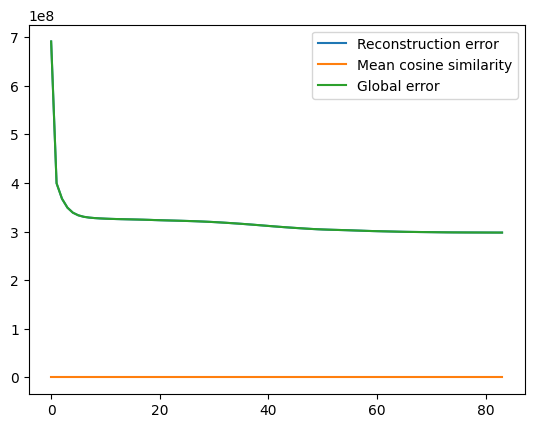

In [30]:
import matplotlib.pyplot as plt

plt.plot(cn.err1, label="Reconstruction error")
plt.plot(cn.err2, label="Mean cosine similarity")
plt.plot(cn.ferr, label="Global error")
plt.legend()
plt.show()

### Step 2
Now we will allow CDState to optimize trade-off between reconstruction error and cosine similarity importance in the objective function. It does it using purity estimates that we calculated above. First, we create object for the global optimization:

In [32]:
cnG = cd.CDState(data, purity, num_bases=k, global_round = True, gene_list = cn.gene_list)

We don't have to provide `gene_list` for the global object, by default CDState would repeat the filtering like in Step 1.

In [33]:
cnG.H = copy.copy(cn.H) # start from proportions found in Step 1
cnG.W = copy.copy(cn.W) # start from sources found in Step 1
cnG.prepare_data()
cnG.factorize()

Starting multiobjective error:  297903840.0
Calculates gradient of Cosine(W)..


2026-05-03 20:14:34,200 [INFO] Error: 296617216.0 (1/100)
2026-05-03 20:14:34,281 [INFO] Error: 295717120.0 (2/100)
2026-05-03 20:14:34,361 [INFO] Error: 295042368.0 (3/100)


L1 =  0.9
L2 =  0.1
Malignant sources:
[2, 1]
Calculates gradient of Cosine(W)..
L1 =  0.9
L2 =  0.1
Malignant sources:
[2, 1]
Calculates gradient of Cosine(W)..
L1 =  0.9
L2 =  0.1
Malignant sources:
[2, 1]


2026-05-03 20:14:34,443 [INFO] Error: 294472288.0 (4/100)
2026-05-03 20:14:34,523 [INFO] Error: 293975008.0 (5/100)
2026-05-03 20:14:34,601 [INFO] Error: 293534816.0 (6/100)


Calculates gradient of Cosine(W)..
L1 =  0.9
L2 =  0.1
Malignant sources:
[2, 1]
Calculates gradient of Cosine(W)..
L1 =  0.9
L2 =  0.1
Malignant sources:
[2, 1]
Calculates gradient of Cosine(W)..
L1 =  0.9
L2 =  0.1
Malignant sources:
[2, 1]


...

Initial round
Malignant sources:
[2, 1]
Initial round
Malignant sources:
[2, 1]
Initial round
Malignant sources:
[2, 1]
Initial round
Malignant sources:
[2, 1]


2026-05-03 20:14:37,616 [INFO] Error: 298412768.0 (52/100)
2026-05-03 20:14:37,669 [INFO] Error: 298375712.0 (53/100)
2026-05-03 20:14:37,722 [INFO] Error: 298340736.0 (54/100)
2026-05-03 20:14:37,775 [INFO] Error: 298307680.0 (55/100)


Initial round
Malignant sources:
[2, 1]
Initial round
Malignant sources:
[2, 1]
Initial round
Malignant sources:
[2, 1]
Initial round
Malignant sources:
[2, 1]


2026-05-03 20:14:37,830 [INFO] Error: 298276256.0 (56/100)
2026-05-03 20:14:37,882 [INFO] Error: 298246272.0 (57/100)
2026-05-03 20:14:37,933 [INFO] Error: 298217536.0 (58/100)
2026-05-03 20:14:37,934 [INFO] Factorization time: 0.06711950483319622 minutes


Initial round
Malignant sources:
[2, 1]
Initial round
Malignant sources:
[2, 1]
Initial round
Malignant sources:
[2, 1]


Similarly, we can also inspect how errors changed:
`err1` shows reconstruction error, `err2` shows cosine similarity and `ferr` shows global error. To account for different ranges, we use scaler as (err1/err2):

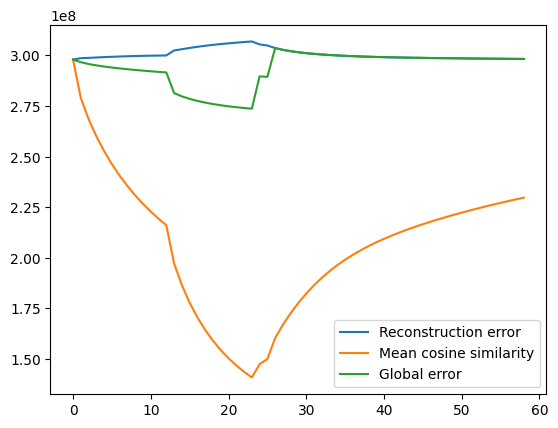

In [87]:
plt.plot(cnG.err1, label="Reconstruction error")
plt.plot(cnG.scaler*cnG.err2, label="Mean cosine similarity")
plt.plot(cnG.ferr, label="Global error")
plt.legend()
plt.show()

On the plot we see that indeed in the Step 2 cosine similarity between the sources dropped substantially.

Now in output, CDState provides us with `cnG.W` representing output source expression, `cnG.H` representing their proporitons and `cnG.mal` a list with indexes of malignant sources. Let's prepare the data for saving. First, we will **infer the source expression for all genes that were filtered out**:

In [54]:
cnG.infer_full()
print(cnG.W.shape, cnG.full_W.shape)

(7563, 4) (23686, 4)


We can then use sources with filtered or full set of genes:

In [57]:
sources_filtered = pd.DataFrame(cnG.W, index = cnG.gene_list)
sources_filtered.columns = ['S' + str(x) for x in range(sources_filtered.shape[1])]

In [58]:
sources_filtered

,S0,S1,S2,S3
IRX4,2.590139e-49,5.398646e-28,2.776805e+00,1.321680e-54
HDC,1.961475e+01,7.639441e-35,1.326754e-12,5.397561e-58
ANKRD30BL,1.309988e-33,1.916751e-18,3.463552e+00,1.233393e-31
LOC100131289,1.268158e+00,1.235626e+00,2.517964e+00,3.441836e-15
SYTL1,9.907857e+00,2.576873e+00,1.643362e-03,2.926875e-03
...,...,...,...,...
PPIB,1.492188e+02,7.346181e+02,4.946660e+02,2.148434e+02
RPL36,2.945686e+02,6.402093e+02,5.009595e+02,2.024697e-01
PABPC1,1.095314e+03,2.331654e+02,4.429216e+02,4.567862e+01
RPL35,4.542231e+02,3.781825e+02,5.979468e+02,2.925491e+00


In [65]:
sources_full = pd.DataFrame(cnG.full_W, index = cnG.raw_data.index.tolist())
sources_full.columns = ['S' + str(x) for x in range(sources_full.shape[1])]

In [66]:
sources_full

,S0,S1,S2,S3
A1BG,2.147599,4.896364,2.818653,5.943333
A1BG-AS1,6.173216,7.283233,4.815870,4.734967
A1CF,0.053207,0.000000,0.226096,0.909670
A2M,1484.644275,131.162928,46.154005,0.000007
A2M-AS1,3.572189,0.827521,2.732001,0.267436
...,...,...,...,...
ZYG11A,3.886008,2.570815,4.550775,5.029299
ZYG11B,11.005458,16.373674,22.939327,9.281079
ZYX,59.045676,198.652026,71.181288,0.015057
ZZEF1,11.126421,13.047495,11.302901,8.465757


In [67]:
malignant_states = sources_full.iloc[:,cnG.mal] # or use sources_filtered
malignant_states

,S2,S1
A1BG,2.818653,4.896364
A1BG-AS1,4.815870,7.283233
A1CF,0.226096,0.000000
A2M,46.154005,131.162928
A2M-AS1,2.732001,0.827521
...,...,...
ZYG11A,4.550775,2.570815
ZYG11B,22.939327,16.373674
ZYX,71.181288,198.652026
ZZEF1,11.302901,13.047495


In [72]:
proportions = pd.DataFrame(cnG.H, index = sources.columns)
proportions.columns = data.columns
malignant_proportions = proportions.iloc[cnG.mal,:]
malignant_proportions = malignant_proportions.T
malignant_proportions

,S2,S1
MGH100,5.103331e-01,4.723008e-01
MGH101,6.955083e-09,7.961063e-01
MGH102,4.823185e-01,5.985369e-02
MGH104,3.486179e-01,6.513821e-01
MGH105,8.122471e-02,5.361679e-01
MGH106,1.893479e-01,7.052737e-01
MGH110,7.893110e-01,5.812237e-02
MGH113,5.141683e-01,3.401383e-01
MGH115,1.183612e-01,8.388865e-01
MGH121,4.724917e-01,4.889343e-01


Finally, we will use malignant proportions to calculate **ITTH index**. It is calculated on relative proportions of malignant states:

In [76]:
sitth = None

if malignant_proportions.shape[1] > 1:
    # recalculate malignant proportions
    H_tri = malignant_proportions.copy()
    H_tri = H_tri.div(H_tri.sum(axis=1), axis=0)

    # calculate SITTH score
    sitth_score = H_tri * np.log2(H_tri)
    sitth_score = sitth_score.fillna(0)
    sitth_score = -sitth_score.sum(axis=1)
    sitth_score = sitth_score / np.log2(malignant_proportions.shape[1])

    malignant_proportions["ITTH"] = sitth_score

malignant_proportions

/home/agnieszka/miniconda3/envs/cdstate/lib/python3.10/site-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: divide by zero encountered in log2
  result = func(self.values, **kwargs)


,S2,S1,ITTH
MGH100,5.103331e-01,4.723008e-01,0.952279
MGH101,6.955083e-09,7.961063e-01,0.000070
MGH102,4.823185e-01,5.985369e-02,0.742849
MGH104,3.486179e-01,6.513821e-01,0.934592
MGH105,8.122471e-02,5.361679e-01,0.774905
MGH106,1.893479e-01,7.052737e-01,0.867283
MGH110,7.893110e-01,5.812237e-02,0.751076
MGH113,5.141683e-01,3.401383e-01,0.925729
MGH115,1.183612e-01,8.388865e-01,0.812064
MGH121,4.724917e-01,4.889343e-01,0.949827


Now, we can save the outputs:

In [88]:
out_states = Path.cwd().parent / "notebooks" / "analysis_states.csv"
out_proportions = Path.cwd().parent / "notebooks" / "analysis_proportions.csv"
malignant_states.to_csv(out_states, index=True)
malignant_proportions.to_csv(out_proportions, index=True)
